# RunPod SSH와 PyCharm 원격 Interpreter 연결하기

**SSH(Secure Shell)** 는 로컬 컴퓨터에서 원격 Linux terminal에 암호화된 연결을 만드는 방식이다. RunPod의 Full SSH는 terminal 명령과 SCP·SFTP 파일 전송을 지원하므로 PyCharm SSH Interpreter가 원격 Python을 실행하고 프로젝트 파일을 동기화하는 기반이 된다.


## 로컬 PC와 RunPod의 SSH 연결 구조

로컬 PC는 private key를 보관하고, RunPod 계정에는 대응하는 public key를 등록한다. RunPod의 public IP와 external SSH port는 Pod 내부 port 22로 전달된다. 인증이 끝나면 terminal 명령은 RunPod Linux에서 실행되고 PyCharm은 같은 연결로 원격 Python 실행과 SFTP 파일 동기화를 수행한다.

```mermaid
flowchart LR
    LOCAL["로컬 PC<br/>terminal·PyCharm"]
    PRIVATE["로컬 private key<br/>id_ed25519"]
    PUBLIC["RunPod 계정<br/>SSH Public Key"]
    GATE["Public IP : External Port"]
    SSHD["Pod SSH Server<br/>Internal Port 22"]
    WORKSPACE["/workspace<br/>코드·데이터·결과"]
    PYTHON["RunPod Python<br/>SSH Interpreter"]

    PRIVATE -->|"서명"| LOCAL
    PUBLIC -->|"public key 대조"| SSHD
    LOCAL -->|"Full SSH"| GATE
    GATE --> SSHD
    SSHD -->|"terminal·SFTP"| WORKSPACE
    WORKSPACE --> PYTHON
```

private key는 네트워크로 전송하거나 RunPod에 업로드하지 않는다. RunPod에는 `.pub` public key만 등록한다.


## 연결 전에 준비할 정보

SSH 설정을 시작하기 전에 다음 항목을 한곳에 기록한다. 실제 public IP와 external port는 공개 문서나 화면 캡처에 남기지 않는다.

1. RunPod Pod 상태가 `Running`인지 확인한다.
2. Pod 생성 시 `SSH terminal access`가 활성화되었는지 확인한다.
3. `Connect → SSH`에서 `SSH over exposed TCP` 명령을 찾는다.
4. 명령에서 `Host`, 외부 `Port`, `Username`을 구분한다.
5. 로컬 PC에서 사용할 개인 키 경로를 확인한다.
6. 원격 작업 경로를 `/workspace` 아래로 정한다.



## SSH 공개 키와 개인 키 준비하기

SSH key pair는 서로 연결된 두 파일이다. **공개 키**는 자물쇠처럼 RunPod 계정에 등록하고, **개인 키**는 열쇠처럼 로컬 PC에만 보관한다. 공개 키가 `id_ed25519.pub`라면 개인 키는 확장자가 없는 `id_ed25519`이다.

기존 키가 있는지 먼저 확인하고, 없을 때만 새 키를 만든다. 아래 명령은 **RunPod terminal이 아니라 로컬 PC의 terminal 또는 Windows PowerShell**에서 실행한다. `-C "runpod-class"`는 key의 용도를 구분하는 comment이며 비밀번호와 다른 단순 식별용 문자열이다.

```bash
# macOS·Linux 또는 Windows OpenSSH
ssh-keygen -t ed25519 -C "runpod-class"
```

명령을 실행하면 다음 세 질문이 순서대로 나타난다. 운영체제와 사용자 이름에 따라 괄호 안의 기본 경로만 달라진다.

```text
Generating public/private ed25519 key pair.
Enter file in which to save the key (.../.ssh/id_ed25519):
Enter passphrase for ".../.ssh/id_ed25519" (empty for no passphrase):
Enter same passphrase again:
```


### 1. key를 저장할 위치 선택하기

`Enter file in which to save the key`에서는 새 key를 기본 이름으로 만들려면 아무것도 입력하지 않고 `Enter`를 누른다.

기본 위치는 macOS·Linux의 `~/.ssh/id_ed25519`, Windows의 `C:\Users\사용자명\.ssh\id_ed25519`이다. 그러면 같은 위치에 public key인 `id_ed25519.pub`도 함께 만들어진다.



### 2. private key의 passphrase 정하기

`Enter passphrase`에서는 private key 파일을 보호할 암호 문구를 입력한다.<br>
 입력하는 동안 문자나 `*`가 화면에 표시되지 않지만 정상적으로 입력되고 있다. <br>
 입력을 마치면 `Enter`를 누르고, `Enter same passphrase again`에서 같은 내용을 한 번 더 입력한다.

실습에서는 두 질문에서 `Enter`만 눌러 빈 passphrase를 사용할 수도 있지만, private key 파일이 유출되면 추가 보호가 없어진다. 가능하면 기억할 수 있는 passphrase를 설정하고, 뒤의 PyCharm 설정에서도 같은 passphrase를 입력한다. 이 값은 RunPod 계정 비밀번호나 API key와는 별개의 로컬 key 보호용 암호이다.


### 3. 생성 결과에서 두 파일 구분하기

완료되면 `Your identification has been saved in ...`은 private key 경로를, `Your public key has been saved in ...`은 `.pub` public key 경로를 뜻한다. 이어서 보이는 `SHA256:...` fingerprint와 randomart는 key를 식별하는 정보이며 RunPod에 붙여 넣을 공개 키 본문과는 다르다.

공개 키 내용을 확인하는 명령은 운영체제에 따라 다르다.

```bash
# macOS·Linux
cat ~/.ssh/id_ed25519.pub
```

```powershell
# Windows PowerShell
Get-Content $env:USERPROFILE\.ssh\id_ed25519.pub
```

RunPod 전용 이름을 사용했다면 위 명령의 파일명을 `id_ed25519_runpod.pub`로 바꾼다.

출력은 `ssh-ed25519`로 시작하고 마지막에 comment가 붙을 수 있다. RunPod에는 이 **한 줄 전체**를 붙여 넣는다. `SHA256:...` fingerprint, 개인 키 본문, Jupyter token과 API key는 등록하지 않는다.


### RunPod에 공개 키 등록하기

RunPod 콘솔의 `Credentials → SSH Public Keys`를 연다.

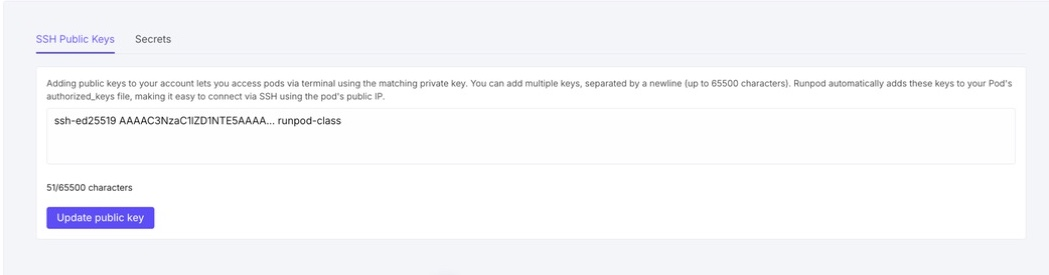

1. `Add SSH Key` 또는 공개 키 입력 영역을 연다.
2. `ssh-ed25519`로 시작하는 `.pub` 파일의 한 줄 전체를 붙여 넣는다.
3. 저장된 key가 목록에 나타나는지 확인한다.
4. 공개 키를 등록한 뒤 새 Pod를 생성하거나 기존 Pod에 key가 반영되었는지 확인한다.

Pod 생성 뒤 계정에 key를 추가하면 기존 Pod의 `authorized_keys`에 자동 반영되지 않을 수 있다. 이 경우 가장 단순한 해결 방법은 필요한 파일을 백업한 뒤 key가 등록된 상태에서 Pod를 다시 배포하는 것이다.

공식 문서: [RunPod SSH key와 접속](https://docs.runpod.io/pods/configuration/use-ssh)


## RunPod에서 Full SSH 접속 정보 찾기

Pod 상태가 `Running`이면 `Connect → SSH`를 연다.

**SSH over exposed TCP** 카드의 명령에서 Username, Public IP와 External Port를 확인한다. <br>
이 값은 각자 다르며 Pod를 다시 시작하면 변경될 수 있다.

```bash
ssh root@RUNPOD_PUBLIC_IP -p EXTERNAL_SSH_PORT -i PATH_TO_PRIVATE_KEY
```

Basic SSH는 RunPod SSH proxy를 통한 terminal 중심 연결이고 SCP·SFTP를 지원하지 않는다. PyCharm의 파일 동기화에는 SSH over exposed TCP를 사용한다.


## 로컬 terminal에서 Full SSH 먼저 검증하기

처음 연결하면 server fingerprint 확인 질문이 나타날 수 있다. RunPod Connect 화면의 Host와 port가 맞는지 다시 확인한 뒤에만 승인한다. 접속 후 prompt가 원격 Linux의 `root@...` 형태로 바뀌면 다음 명령을 순서대로 실행한다.

```bash
cd /workspace
pwd
whoami
hostname
which python
python --version
nvidia-smi
```

`pwd`는 `/workspace`, `whoami`는 template 사용자, `which python`은 원격 Python 경로를 보여야 한다. 이때 확인한 Python 경로를 뒤의 PyCharm Interpreter 설정에 사용한다. `nvidia-smi`가 GPU를 보여도 PyTorch의 CUDA 사용 가능 여부는 아직 별도로 확인해야 한다.



## PyCharm SSH Interpreter가 하는 일

PyCharm은 RunPod 전용 Client가 아니라 표준 SSH·SFTP 기능을 사용한다. **SSH Interpreter**는 `.py` 실행과 Python package 인식에 사용할 원격 Python을 정하고, **Deployment/SFTP mapping**은 로컬 파일을 RunPod의 작업 폴더로 전송한다.

PyCharm의 원격 SSH Interpreter는 라이선스와 제품 version에 따라 제공 범위가 달라질 수 있다. `On SSH` 메뉴가 보이지 않으면 01번 노트북의 RunPod JupyterLab 경로를 사용한다. 메뉴가 있더라도 terminal Full SSH가 성공한 뒤 설정한다.

공식 문서: [PyCharm SSH Interpreter](https://www.jetbrains.com/help/pycharm/configuring-remote-interpreters-via-ssh.html)


### PyCharm에서 SSH 연결 정보 입력하기

`Settings → Python → Interpreter → Add Interpreter → On SSH`로 이동한다. 아래 이미지는 PyCharm 2026.1.5에서 SSH Interpreter를 추가한 화면이며 version과 운영체제에 따라 메뉴 이름과 위치가 조금 달라질 수 있다.

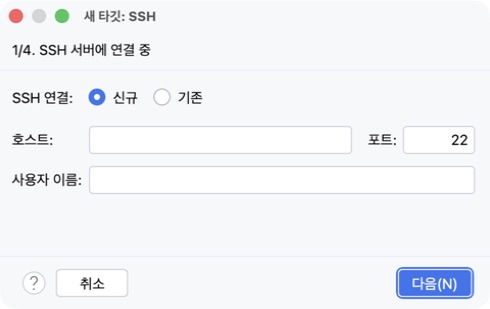

RunPod `Connect → SSH over exposed TCP`의 값을 다음처럼 옮긴다.

1. **Host**: RunPod 공개 IP를 입력한다.
2. **Port**: 내부 port 22가 아니라 RunPod가 할당한 외부 port를 입력한다.
3. **Username**: Connect 화면의 사용자 이름을 입력한다. 공식 PyTorch template에서는 일반적으로 `root`이다.

`Test Connection` 또는 `Next`가 실패하면 PyCharm에서 값을 바꾸기 전에 같은 Host·port·key의 terminal SSH가 여전히 성공하는지 다시 확인한다. 연결 정보 입력만으로는 Python 코드를 실행할 수 없으므로 다음 단계에서 원격 Python과 프로젝트 경로까지 선택한 뒤 확인 코드를 실행한다.


### 원격 Python과 Notebook 동기화 위치 선택하기

SSH 인증 다음 단계에서 PyCharm은 **Python 실행 환경**과 **프로젝트 동기화 위치**를 설정한다. 두 경로는 역할이 다르다. 이번 실습에서는 가상환경과 영구 저장 경로를 다음처럼 구분한다.

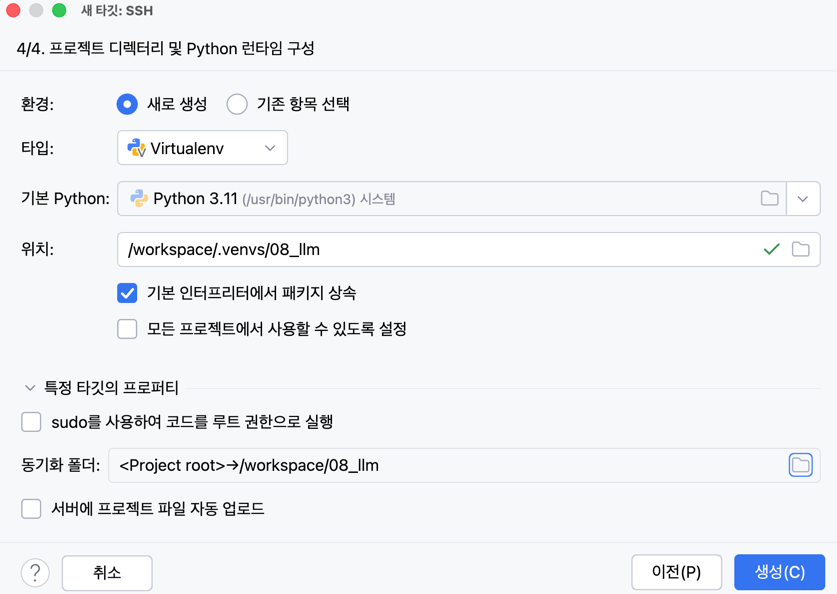
```text
가상환경: /workspace/.venvs/08_llm
Notebook 실행용 임시 복사본: /tmp/pycharm_project_*
모델 cache와 학습 결과: /workspace 아래의 명시적인 폴더

```

#### 화면 항목별 설정

1. **환경**: 처음 만드는 경우 `새로 생성`, 같은 Network Volume에 기존 가상환경이 남아 있으면 `기존 항목 선택`을 사용한다.

2. **타입**: 새 환경은 `Virtualenv`를 선택한다.

3. **기본 Python**: RunPod terminal에서 `python -c "import sys; print(sys.executable)"`로 확인한 경로를 선택한다. 기본 환경의 PyTorch를 상속하려면 같은 Python에서 `import torch`와 CUDA 사용 여부가 정상인지 먼저 확인한다.

4. **위치**: 가상환경 폴더인 `/workspace/.venvs/08_llm`을 입력한다. `/workspace` 자체는 여러 파일을 보관하는 상위 폴더이므로 가상환경 위치로 직접 사용하지 않는다.

5. **기본 인터프리터에서 패키지 상속**: RunPod template에 설치된 PyTorch와 CUDA package를 새 가상환경에서도 사용하려면 체크한다. 이번 실습에서는 체크한다. 완전히 독립된 환경을 만들고 package를 모두 다시 설치할 때만 체크하지 않는다.

6. **모든 프로젝트에서 사용할 수 있도록 설정**: 현재 실습 프로젝트에만 연결하므로 체크하지 않는다.

7. **동기화 폴더와 자동 업로드**: `<Project root> → /workspace`로 두고 자동 업로드를 켜면 현재 PyCharm 프로젝트 전체가 전송 대상이 된다. 범위를 줄이려면 실습에 필요한 폴더만 별도 PyCharm 프로젝트로 열거나 자동 업로드를 끄고 필요한 파일만 전송한다.

#### 저장 위치에 따른 차이

- `/root/.virtualenvs/08_llm`: Pod의 container 영역이므로 Pod를 삭제하면 함께 사라질 수 있다.
- `/workspace/.venvs/08_llm`: `/workspace`에 연결한 저장소를 사용한다. 새 Pod에서도 재사용하려면 같은 **Network Volume**을 다시 연결해야 한다.

새 Pod의 template이나 Python version이 달라졌다면 기존 가상환경을 억지로 재사용하지 않고 다시 만드는 편이 안전하다.

가상환경 생성을 마치면 PyCharm이 사용하는 실행 파일은 `/workspace/.venvs/08_llm/bin/python`이 된다. PyCharm Notebook은 로컬 프로젝트를 `/tmp/pycharm_project_*` 아래에 임시로 동기화하여 실행할 수 있다. 따라서 Notebook의 현재 작업 폴더가 `/workspace`가 아니어도 원격 실행 오류가 아니다. 처음 동기화할 때는 다음 항목을 전송 대상에서 제외한다.

- `.env`, SSH private key와 token 파일
- `.git`, `.idea`, `__pycache__`, 로컬 `.venv`
- Hugging Face cache, checkpoint와 merged model처럼 큰 결과물

상대 경로로 파일을 저장하면 `/tmp/pycharm_project_*` 아래에 생성될 수 있다. 다시 사용할 모델 cache, dataset, checkpoint와 학습 결과는 `Path('/workspace/...')`처럼 `/workspace` 아래의 절대경로를 명시한다. 같은 파일을 양쪽에서 동시에 편집하면 덮어쓸 수 있으므로 실습 중 편집 위치를 하나로 정한다.

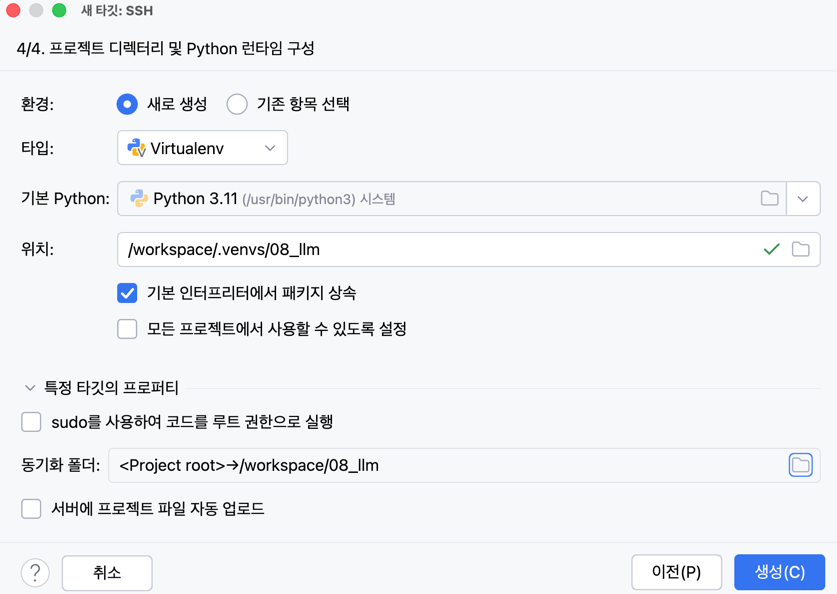

### PyCharm에 RunPod External Jupyter Server 연결하기

PyCharm에서 원격 Python을 등록하는 것과 원격 Notebook kernel을 연결하는 것은 서로 다른 설정이다.

- **SSH Interpreter**: `.py` 파일 실행, 원격 package 관리와 SFTP 파일 전송에 사용한다.
- **External Jupyter Server**: `.ipynb` 코드셀을 RunPod에서 실행하며, Pod 시작 시 주입된 `HF_TOKEN`, `OPENAI_API_KEY` 같은 환경변수를 상속한다.

현재 실습에서는 두 연결을 모두 사용한다. SSH Interpreter를 선택해도 Notebook kernel은 자동으로 바뀌지 않으므로 External Jupyter Server와 kernel을 별도로 선택해야 한다.

#### RunPod 가상환경을 Jupyter kernel로 등록하기

RunPod Web terminal 또는 앞에서 연결한 Full SSH terminal에서 다음 명령을 실행한다. 첫 번째 명령은 가상환경에 `ipykernel`을 설치하고, 두 번째 명령은 같은 Python을 `Python (08_llm)`이라는 kernel로 등록한다.

```bash
/workspace/.venvs/08_llm/bin/python -m pip install ipykernel
/workspace/.venvs/08_llm/bin/python -m ipykernel install --user --name 08_llm --display-name "Python (08_llm)"
```

#### PyCharm에 External Jupyter Server 등록하기

1. RunPod에서 `Connect → HTTP Services → JupyterLab`을 열어 현재 Jupyter URL을 확인한다.
2. PyCharm에서 `Tools → Add Jupyter Connection`을 선택한다.
3. `External Server`와 `Notebook/Lab`을 선택하고 RunPod Jupyter URL을 입력한다.
4. 인증 화면이 나타나면 RunPod가 제공한 token 또는 설정한 password를 입력한다.
5. `Test connection`으로 연결을 확인한다.
6. Notebook 상단에서 방금 등록한 RunPod External Server와 `Python (08_llm)` kernel을 선택한다.

Jupyter URL, token과 password는 인증 정보이므로 출력, 화면 캡처나 Git에 남기지 않는다.


### PyCharm Notebook이 RunPod에서 실행되는지 확인하기

RunPod External Jupyter Server와 `Python (08_llm)` kernel을 선택한 뒤 아래 셀을 실행한다. SSH Interpreter 선택만으로 Notebook kernel이 자동 변경되지는 않는다. PyCharm 하단의 Terminal은 로컬 terminal일 수 있으므로 화면 위치가 아니라 코드가 출력한 Python 경로와 GPU 정보로 실행 위치를 판단한다.

PyCharm은 Notebook을 실행할 때 프로젝트 파일을 `/tmp/pycharm_project_*`에 임시로 올릴 수 있다. 이 경로는 정상적인 동작이며 `/workspace` 아래인지 검사하지 않는다.

`platform.node()`는 실행 Host, `sys.executable`과 `sys.prefix`는 선택한 원격 가상환경, `Path.cwd()`는 이번 Notebook 복사본의 실행 위치를 보여 준다. `platform`이 `Linux`이고 가상환경이 `/workspace/.venvs/08_llm`이며 `nvidia-smi` 결과가 나오면 원격 Notebook 연결이 완료된 것이다. 환경변수는 실제 값 대신 설정 여부만 `True` 또는 `False`로 확인한다.


In [1]:
from pathlib import Path
import os
import platform
import subprocess
import sys

working_directory = Path.cwd().resolve()
expected_environment = Path("/workspace/.venvs/09_llm").resolve()
current_environment = Path(sys.prefix).resolve()

print("host:", platform.node())
print("platform:", platform.system())
print("python:", sys.executable)
print("environment:", current_environment)
print("working directory:", working_directory)

# 실제 secret 값은 노출하지 않고 현재 kernel의 환경변수 설정 여부만 확인한다.
print("HF_TOKEN configured:", bool(os.getenv("HF_TOKEN")))
print("OPENAI_API_KEY configured:", bool(os.getenv("OPENAI_API_KEY")))

gpu_result = subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total",
        "--format=csv,noheader",
    ],
    # check=True는 명령 실패를 예외로 바꾼다.
    check=True,
    # capture_output=True는 GPU 정보를 stdout 변수에 담는다.
    capture_output=True,
    # text=True는 bytes 대신 문자열로 결과를 받는다.
    text=True,
)

gpu_info = gpu_result.stdout.strip()
print("gpu:", gpu_info)

# 원격 Linux, 수업용 가상환경과 GPU 사용 가능 여부만 확인한다.
assert platform.system() == "Linux", "Linux 원격 환경이 아니다."
assert current_environment == expected_environment, (
    "선택한 kernel이 수업용 원격 가상환경이 아니다: "
    f"{current_environment}"
)
assert gpu_info, "GPU 정보를 확인할 수 없다."

print("RunPod Notebook 실행 확인 완료")

# 실행 결과:
# - platform은 Linux이고 python과 environment는 /workspace/.venvs/08_llm을 가리킨다.
# - working directory는 /tmp/pycharm_project_*일 수 있으며 gpu에는 GPU 이름과 VRAM이 표시된다.
# - HF_TOKEN과 OPENAI_API_KEY는 실제 값 없이 configured의 True/False만 표시된다.
# 알 수 있는 것:
# - 임시 작업 폴더와 관계없이 원격 가상환경과 GPU가 확인되면 RunPod에서 실행 중이다.
# - 환경변수가 False여도 연결 검증은 계속되며, 필요한 실습 전에 RunPod 설정을 확인한다.
# - 영구 보관할 파일은 /workspace 아래의 절대경로로 저장해야 한다.

host: 4a271450f893
platform: Linux
python: /usr/local/bin/python
environment: /usr
working directory: /
HF_TOKEN configured: False
OPENAI_API_KEY configured: False
gpu: NVIDIA A40, 46068 MiB


AssertionError: 선택한 kernel이 수업용 원격 가상환경이 아니다: /usr

## Pod Stop·재시작 뒤 SSH와 Jupyter 다시 연결하기

Stop하면 GPU 할당이 반환되며 다시 시작할 때 같은 GPU 재고가 없을 수 있다. Public IP, External SSH Port와 External Jupyter URL이 달라질 수도 있다.

1. Pod 상태가 다시 `Running`인지 확인한다.

2. `Connect → SSH`에서 현재 SSH over exposed TCP 명령을 확인한다.

3. 로컬 terminal Full SSH를 먼저 재검증한다.

4. Host 또는 Port가 바뀌었다면 PyCharm SSH configuration을 수정한다.

5. `Connect → HTTP Services → JupyterLab`에서 현재 URL을 다시 확인하고 PyCharm External Jupyter connection을 갱신한 뒤 `Test connection`을 실행한다.

6. Notebook에서 RunPod External Server와 `Python (08_llm)` kernel을 다시 선택하고 필요하면 kernel을 재시작한다.

7. 확인 셀을 다시 실행해 `/workspace/.venvs/08_llm/bin/python`, GPU와 환경변수 설정 여부를 확인한다. `/tmp/pycharm_project_*` 작업 폴더는 다시 만들어질 수 있으며 정상이다.

Terminate하면 Pod와 일반 Volume이 삭제되므로 SSH 재연결 대상도 사라진다.
